<font size = "5"> **Day 2: [Electron Diffraction and 4D‑STEM](../MLSTEM2026.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />


MLSTEM2026


[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day2/11AM_Dynamic_Diffraction.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day2/11AM_Dynamic_Diffraction.ipynb)


# Analyzing CBED Pattern

Lecturer: Gerd Duscher

part of the workshop of 

<font size = "5"> **[Machine Learning for Electron Microscopy](../MLSTEM2025.ipynb)**</font>


**Day2: Electron Diffraction and 4D‑STEM**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**June 2026**

## Overview
We calculate CBED pattern for a scanned area to demonstrate how to derive DPC from CBED pattern of 4D-STEM data set or from images obtained with segmented detectors.

This is important to get training data for further machine learning algorithms and for an understanding of the physical content of the data. 

## Load packages
### Check for Newest Versions



## Load relevant python packages
### Check Installed Packages

In [1]:
import sys
from pkg_resources import get_distribution, DistributionNotFound

def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = get_distribution(package_name).version
    except (DistributionNotFound, ImportError) as err:
        version = '-1'
    return version


# pyTEMlib setup ------------------
if test_package('pyTEMlib') < '0.2025.1.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install  --upgrade pyTEMlib -q
# ------------------------------
print('done')

C:\Users\gduscher\AppData\Local\Temp\ipykernel_12584\2305901029.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import get_distribution, DistributionNotFound


installing pyTEMlib
done


### Import numerical and plotting python packages
Import the python packages that we will use:

Beside the basic numerical (numpy) and plotting (pylab of matplotlib) libraries,

and some libraries from the book
* kinematic scattering library.
* file_tools library

In [20]:
%matplotlib  widget
import matplotlib.pyplot as plt
import numpy as np
import sys

if 'google.colab' in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
    from google.colab import drive

# additional package 
import os
import itertools 
import scipy.constants as const

#import ipywidgets as ipyw

import pyTEMlib

__notebook_version__ = '2026.06.22'

print('pyTEM version: ', pyTEMlib.__version__)
print('notebook version: ', __notebook_version__)

pyTEM version:  0.2026.6.0
notebook version:  2026.06.22


## Load CBED Pattern from example_data of Day2

First we select the diffraction pattern with the FileWidget

In [24]:
if 'google.colab' in sys.modules:
    drive.mount("/content/drive")
    if not os.path.exists('./CBED_375mm_alpha-3.3_beta9.6_Condensor10um_Filter.dm3'):
        !wget  https://github.com/gduscher/MLSTEM2026//raw/main/example_data/CBED_375mm_alpha-3.3_beta9.6_Condensor10um_Filter.dm3
fileWidget = pyTEMlib.file_tools.FileWidget('.')    

[np.float64(-0.2016160637140274), np.float64(825.6177809089422), np.float64(825.6177809089422), np.float64(-0.2016160637140274)]


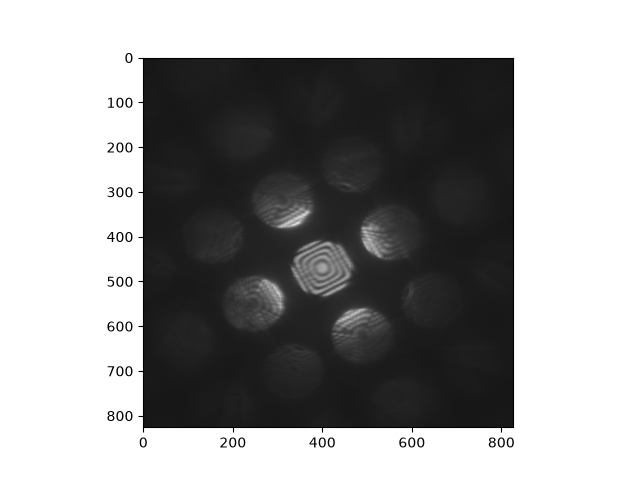

In [25]:
diff_pattern = fileWidget.selected_dataset
diff_pattern -= diff_pattern.min()

diff_pattern[diff_pattern<0] = 0.
extent = diff_pattern.get_extent([0,1])
print(extent)
fig = plt.figure() 
plt.imshow(diff_pattern,cmap="gray", extent=extent);
plt.show()

What to look for? 
 - symmetry - center
 - symmetry - whole pattern
 - how many fringes in center 

### Plotting on a logarithmic scale

The dynamic range in diffraction data is even larger than in images and so for a good presentation of the data it is advantagous to go to plot the intensities in a logarythmic scale.

To present data in logarythmic scale no nexgative values (noise) can be in these data and so all negative values in the dataset will be set to zero.

The factor 1 in front of the diffraction pattern in the log numpy function in the ``imshow`` is the gamma value.
Changing that value will change the contrast.

[np.float64(-0.2016160637140274), np.float64(825.6177809089422), np.float64(825.6177809089422), np.float64(-0.2016160637140274)]


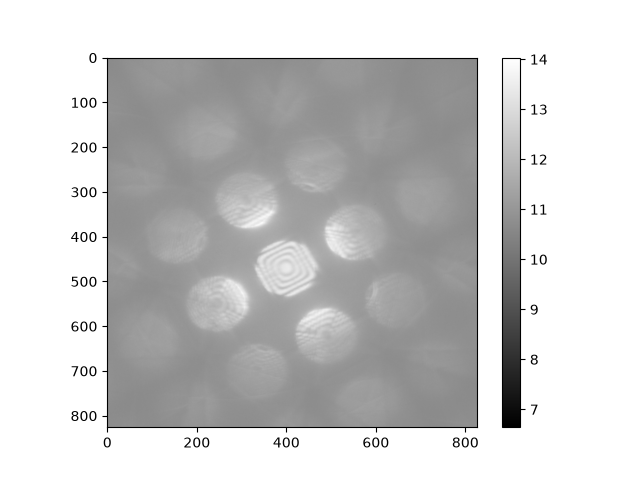

In [26]:
diff_pattern = fileWidget.selected_dataset
diff_pattern -= diff_pattern.min()

diff_pattern[diff_pattern<0] = 0.
extent = diff_pattern.get_extent([0,1])
print(extent)
plt.figure() 
plt.imshow(np.log2(100+diff_pattern),cmap="gray", extent=extent)
plt.colorbar()
plt.show()

## Finding the center

### Selection of  center disk

Select the center disk with the ring selector


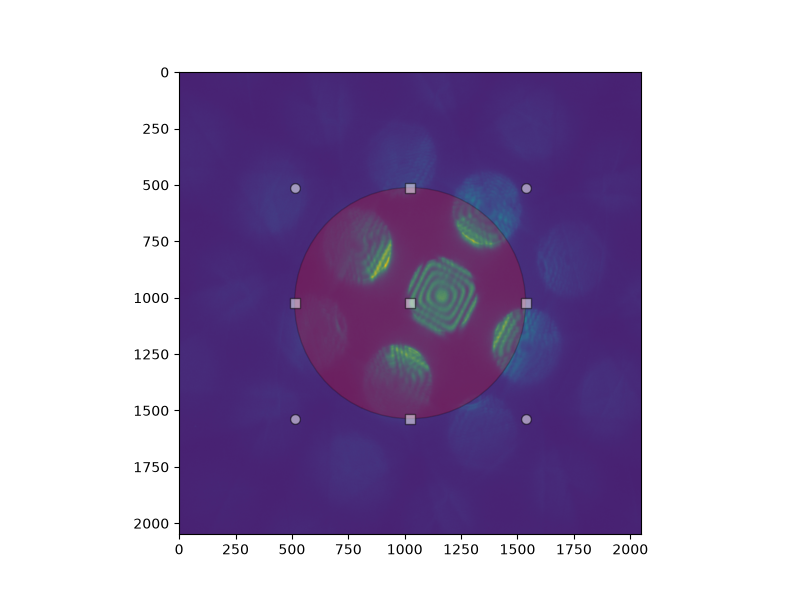

In [27]:
from matplotlib.widgets import  EllipseSelector

center = np.array([diff_pattern.shape[0]/2, diff_pattern.shape[1]/2])

plt.figure(figsize=(8, 6))
plt.imshow(diff_pattern.T, origin = 'upper')
selector = EllipseSelector(plt.gca(), None,interactive=True)  # gca get current axis (plot)
radius = diff_pattern.shape[0]/4
center = np.array(center)

selector.extents = (center[0]-radius,center[0]+radius,center[1]-radius,center[1]+radius)
plt.show()

### Read out center and radius

In [28]:
xmin, xmax, ymin, ymax = selector.extents
x_center, y_center = selector.center
x_shift = x_center - diff_pattern.shape[0]/2
y_shift = y_center - diff_pattern.shape[1]/2
print(f'radius x-direction = {(xmax-xmin)/2:.0f} pixels')
print(f'radius y-direction = {(ymax-ymin)/2:.0f} pixels')

center = (x_center, y_center )
print(f'new center = {center} [pixels]')

out_tags ={}
out_tags['center'] = center

radius x-direction = 512 pixels
radius y-direction = 512 pixels
new center = (np.float64(1170.2857142857142), np.float64(997.4025974025976)) [pixels]


## Calculate Spot Pattern

see [Plotting of Diffraction Pattern](../Diffraction/CH2_08-Spot_Diffraction_Pattern.ipynb) for details

 * For your diffraction pattern you need to change the appropriate zone_axis


In [29]:
# ------ Input --------
zone_axis = [0, 0, 1]
# ---------------------

#Initialize the dictionary of the input
tags_experiment = {}
### Define Crystal
atoms  = pyTEMlib.crystal_tools.structure_by_name('silicon')

### Define experimental parameters:
tags_experiment['acceleration_voltage_V'] = 200.0 *1000.0 #V
tags_experiment['new_figure'] = False
tags_experiment['plot FOV'] = 30
tags_experiment['convergence_angle_mrad'] = 0
tags_experiment['zone_hkl'] = np.array(zone_axis)  # incident neares zone axis: defines Laue Zones!!!!
tags_experiment['mistilt']  = np.array([0,0,0])  # mistilt in degrees
tags_experiment['Sg_max'] = .05 # 1/nm  maximum allowed excitation error ; This parameter is related to the thickness
tags_experiment['hkl_max'] = 15   # Highest evaluated Miller indices

atoms.info['experimental'] = tags_experiment
######################################
# Diffraction Simulation of Crystal #
######################################

tags_simulation = pyTEMlib.diffraction_tools.get_bragg_reflections(atoms, tags_experiment, verbose=True)


Of the 504 possible reflection 108 are allowed.
Of those, there are 28 in ZOLZ  and 80 in HOLZ
Of the 212 forbidden reflection in ZOLZ  0 can be dynamically activated.


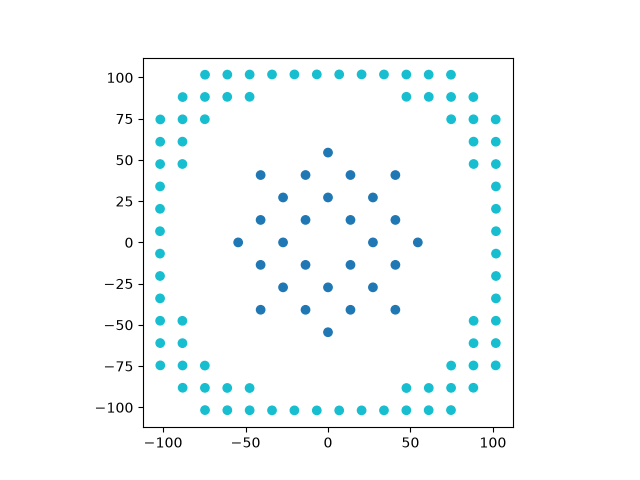

In [30]:
# ------ Input -------------
rotation = 0
# -------------------------
rotation = np.radians(rotation)
# ########################
# Plot ZOLZ SAED Pattern #
# ########################

spots = pyTEMlib.diffraction_tools.plotting_coordinates(tags_simulation['allowed']['g'], rotation=rotation)

plt.figure()
plt.scatter(spots[:,0], spots[:, 1], cmap='tab10', c=tags_simulation['allowed']['Laue_Zone'])
plt.gca().set_aspect('equal')

## Plotting Experimental and Simulated Spot Diffraction Patterns

There is a problem with those diffraction pattern and they did not store the scale.
So I am using an approximate one and you'll have to change that.

Please adjust the roation angle, convergence angle and pixel_size to match your diffraction pattern.

Scale is 0.0020 1/nm per pixel


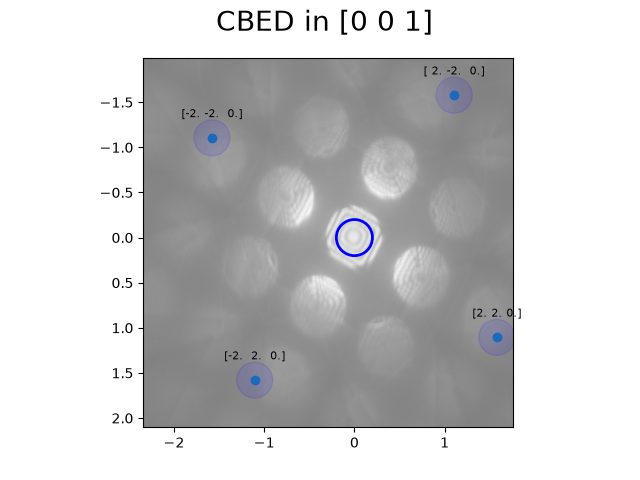

In [31]:
# ----- Input ---------
rotation_angle = -10 # in degrees
convergence_angle = .20  # in 1/nm
pixel_size = 20*1e-4 *1
# -------------------

rotation = np.radians(rotation_angle)

#scale_300mm

g = gx = gy = pixel_size

print(f'Scale is {g:.4f} 1/nm per pixel')
extent= np.array([-center[0]*gx, (diff_pattern.shape[0]-center[0])*gx,(diff_pattern.shape[1]-center[1])*gy, -center[1]*gy])

spots = pyTEMlib.diffraction_tools.plotting_coordinates(tags_simulation['allowed']['g'], rotation=rotation)/10  # now in 1/nm


spots_ZOLZ = spots[tags_simulation['allowed']['ZOLZ']]
fig = plt.figure()
fig.suptitle(' CBED in ' + str(tags_experiment['zone_hkl']), fontsize=20) 
# plt.scatter(spots_ZOLZ[:,0], spots_ZOLZ[:,1], c='red',  alpha = 0.2,   label='spots')
plt.imshow(np.log2(1+diff_pattern).T,cmap="gray", extent=(extent), vmin=np.max(np.log2(1+diff_pattern))*0.5);
plt.scatter(spots[:,0], spots[:, 1] )

plt.xlim(extent[0], extent[1])
plt.ylim(extent[2], extent[3])

for i, spot in  enumerate(spots):
    if np.linalg.norm(spot) < extent[1]*1.2:
        disk = plt.Circle((spot[0], spot[1] ), radius=convergence_angle, alpha=0.1, color='blue')
        plt.gca().add_artist(disk) 
        plt.text(spot[0], spot[1]-.2,str(tags_simulation['allowed']['hkl'][i]),
                  fontsize = 8, horizontalalignment = 'center', verticalalignment ='bottom')

circle = plt.Circle((0, 0), radius=convergence_angle, edgecolor='blue', facecolor="None", linewidth=2)

# 3. Add the patch to the axis
plt.gca().add_patch(circle)

plt.show()


### What does the above figure convey?




### What is the accuracy?




## Conclusion

We need more information for the spot pattern than for the ring pattern.

The convergent beam pattern has the same kinematic diffraciton information but provides additional dynamical diffraction information.

A comparison between simulation and experiment can be very precise.

In principle, if you have the spots and the approximate center you can let an optimization routine do all the scaling for you (which we will do in the high resultion imaging section).

